In [35]:
import pandas as pd

In [36]:
dataset = pd.read_csv('insurance.csv')

In [37]:
dataset.shape

(1338, 7)

In [38]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [39]:
dataset.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [40]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


3 váriaveis são texto, Region, Sex e Smoker. Dessas 2, smoker é 0 ou 1, as outras podemos dividir em multiplas colunas



In [41]:
dataset['smoker'] = dataset['smoker'].map({'yes': 1, 'no': 0})

In [42]:
display(dataset.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520


In [43]:
import sklearn as sk

In [44]:
# Restaurando a coluna do dataframe original em memória e aplicando o mapeamento
dataset['sex'] = dataset_original['sex'].map({'male': 0, 'female': 1})

display(dataset.head())

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [45]:
# Aplicando One-Hot Encoding na coluna 'region' com valores 0 e 1
dataset = pd.get_dummies(dataset, columns=['region'], prefix='region', dtype=int)

# Exibindo o resultado final
display(dataset.head())

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


In [46]:
X = dataset.drop(columns=['charges'])
Y = dataset['charges']

In [48]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, Y, test_size=0.2, random_state=42)

In [53]:
# O erro ocorria porque KNeighborsClassifier é para categorias, e 'charges' é um valor contínuo.
# Alterado para KNeighborsRegressor.
model = sk.neighbors.KNeighborsRegressor(n_neighbors=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Exibindo as primeiras previsões para verificar o resultado
print(y_pred[:5])

[ 8902.96003333  5293.18255    19200.40663333  9607.59981667
 13556.32402667]


In [55]:
# Para regressão, usamos R2 Score ou MSE em vez de Accuracy
r2_score = sk.metrics.r2_score(y_test, y_pred)
print(f'R² Score (Coeficiente de Determinação): {r2_score:.2f}')

# Também podemos ver o erro médio absoluto
mae = sk.metrics.mean_absolute_error(y_test, y_pred)
print(f'Erro Médio Absoluto (MAE): {mae:.2f}')

R² Score (Coeficiente de Determinação): 0.17
Erro Médio Absoluto (MAE): 7143.10


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# 1. Normalizando os dados (importante para modelos baseados em distância)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Testando um modelo mais robusto: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Random Forest não exige escala, mas vamos comparar
y_pred_rf = rf_model.predict(X_test)

# Avaliando o novo modelo
r2_rf = sk.metrics.r2_score(y_test, y_pred_rf)
mae_rf = sk.metrics.mean_absolute_error(y_test, y_pred_rf)

print(f'Novo R² Score (Random Forest): {r2_rf:.2f}')
print(f'Novo Erro Médio Absoluto (MAE): {mae_rf:.2f}')

Novo R² Score (Random Forest): 0.86
Novo Erro Médio Absoluto (MAE): 2571.77


In [57]:
# Reexecutando o KNN com dados escalonados
knn_scaled = sk.neighbors.KNeighborsRegressor(n_neighbors=3)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)

# Avaliando o desempenho
r2_knn_scaled = sk.metrics.r2_score(y_test, y_pred_knn_scaled)
mae_knn_scaled = sk.metrics.mean_absolute_error(y_test, y_pred_knn_scaled)

print(f'R² Score (KNN com Escalonamento): {r2_knn_scaled:.2f}')
print(f'MAE (KNN com Escalonamento): {mae_knn_scaled:.2f}')

R² Score (KNN com Escalonamento): 0.80
MAE (KNN com Escalonamento): 3443.06


R² Score (XGBoost): 0.87


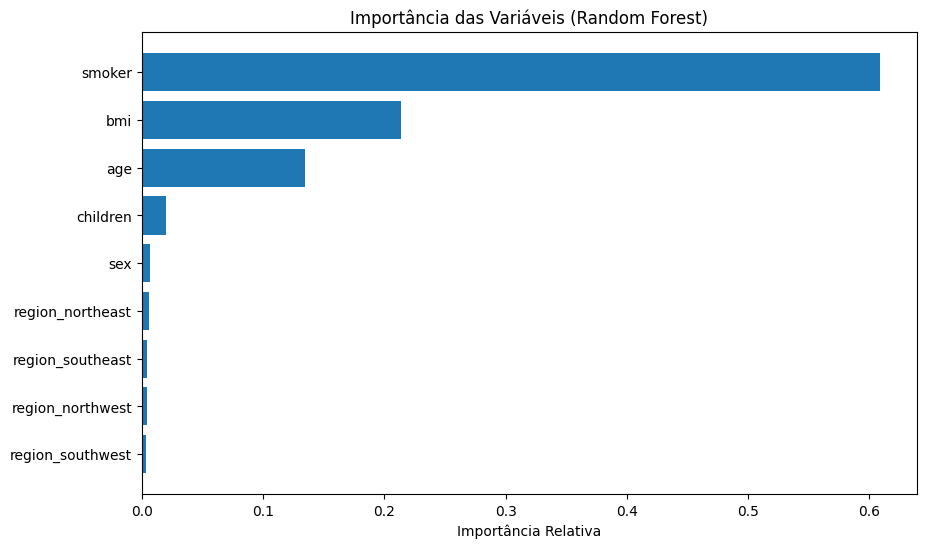

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from xgboost import XGBRegressor

# 1. Treinando o XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Avaliação do XGBoost
r2_xgb = sk.metrics.r2_score(y_test, y_pred_xgb)
print(f'R² Score (XGBoost): {r2_xgb:.2f}')

# 2. Visualizando a Importância das Variáveis (usando o Random Forest anterior)
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importância das Variáveis (Random Forest)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importância Relativa')
plt.show()

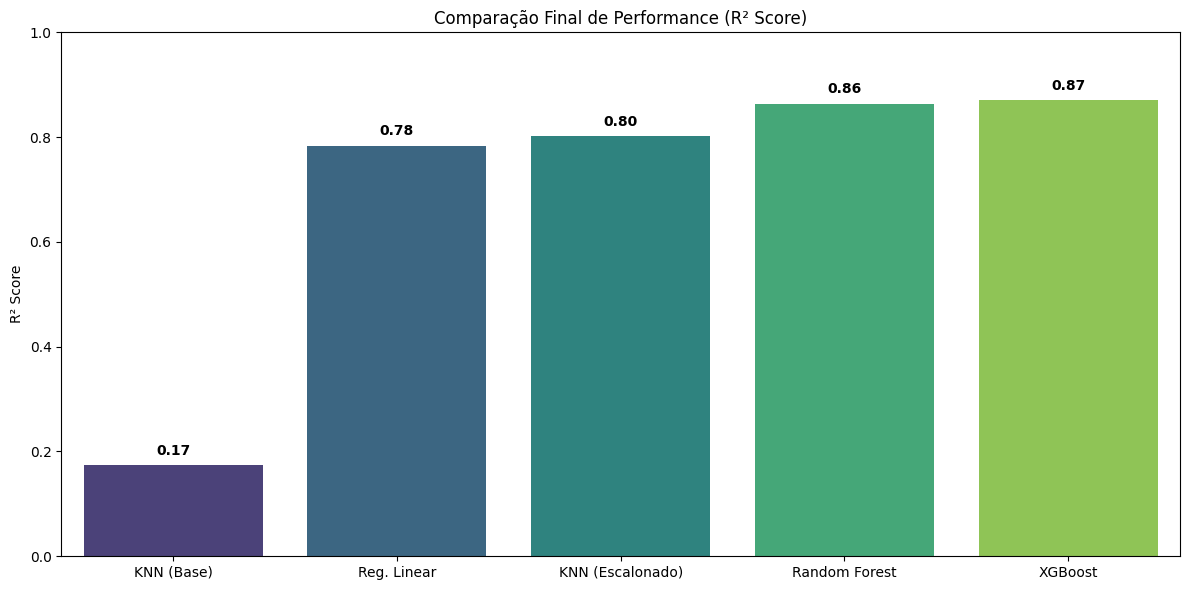

In [62]:
# Comparação final atualizada com Regressão Linear
modelos = ['KNN (Base)', 'Reg. Linear', 'KNN (Escalonado)', 'Random Forest', 'XGBoost']
resultados = [r2_score, r2_lr, r2_knn_scaled, r2_rf, r2_xgb]

plt.figure(figsize=(12, 6))
sns.barplot(x=modelos, y=resultados, hue=modelos, palette='viridis', legend=False)
plt.title('Comparação Final de Performance (R² Score)')
plt.ylim(0, 1)
plt.ylabel('R² Score')

for i, v in enumerate(resultados):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [61]:
from sklearn.linear_model import LinearRegression

# Treinando a Regressão Linear Clássica
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Avaliação
r2_lr = sk.metrics.r2_score(y_test, y_pred_lr)
mae_lr = sk.metrics.mean_absolute_error(y_test, y_pred_lr)

print(f'R² Score (Linear Regression): {r2_lr:.2f}')
print(f'MAE (Linear Regression): {mae_lr:.2f}')

R² Score (Linear Regression): 0.78
MAE (Linear Regression): 4181.19


### Resumo dos Modelos
- **Baseados em Árvores (RF, XGBoost):** Ótimos para capturar interações complexas (ex: fumante + IMC alto = custo muito maior).
- **Lineares (Linear Regression):** Bons para entender o impacto direto de cada variável.
- **Distância (KNN):** Simples, mas dependem totalmente da escala dos dados.